In [1]:
import sys
sys.path.insert(0, "/users/eleves-a/2023/roman.lendormy/reinforcement_learning/Project/RL_project/src")

In [2]:
from mct.train import TrainConfig, run

In [3]:
cfg = TrainConfig(
    steps            = 100_000_000,
    load             = "/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt",
    n_envs           = 8,
    lr               = 5e-5, #ex 3e-4
    gamma            = 0.995,
    ent_coef         = 0.03,
    vf_coef          = 0.25,
    clip_eps         = 0.1,
    epochs           = 8,
    n_steps          = 1024, #ex 512
    batch            = 4096, #ex 2048
    gae_lambda       = 0.99, #ex 0.98
    checkpoint_every = 500_000,
    checkpoint_dir   = "/Data/roman.lendormy/rl_checkpoints_2",
    save             = "/Data/roman.lendormy/rl_checkpoints_2/ppo_blockblast.pt",
    plot             = "/Data/roman.lendormy/rl_checkpoints_2/training_curves.png",
)
trainer, history = run(cfg)

trainer.save("/Data/roman.lendormy/rl_checkpoints_2/ppo_blockblast_final.pt")

Device : cpu
Checkpointing every 500,000 steps -> /Data/roman.lendormy/rl_checkpoints_2/
Loaded <- /Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt  (step 42,516,480 | mean_ret 164.3 over last 100 eps)

PPO -- 100,000,000 steps  12207 updates  8 envs

   Upd |      Steps |   MeanRet |    MedRet |  MeanLen |   PgLoss |   VfLoss |  Entropy |  ClipFr
-------------------------------------------------------------------------------------------------
     1 | 42,524,672 |    222.12 |    161.90 |     24.0 |  -0.0033 |  86.7704 |   1.1096 |   0.078
Saved -> /Data/roman.lendormy/rl_checkpoints_2/ckpt_42524k.pt  (step 42,524,672)
  Plot saved -> /Data/roman.lendormy/rl_checkpoints_2/ckpt_42524k_curves.png
[checkpoint @ 42,524,672]  model -> /Data/roman.lendormy/rl_checkpoints_2/ckpt_42524k.pt  |  plot -> /Data/roman.lendormy/rl_checkpoints_2/ckpt_42524k_curves.png
    10 | 42,598,400 |    206.89 |    136.95 |     23.4 |  -0.0017 |  83.2676 |   1.1006 |   0.050
    20 | 42,680,320 |    183.53 

KeyboardInterrupt: 

In [ ]:
import sys
import torch
sys.path.insert(0, "/users/eleves-a/2023/roman.lendormy/reinforcement_learning/Project/RL_project/src")

from mct.train import TrainConfig, run
from mct.ppo_agent import PPOTrainer
from blockblast.block_blast_3p_env import BlockBlast3PEnv

# Recréer un trainer vide puis charger le checkpoint
envs = [BlockBlast3PEnv() for _ in range(1)]  # 1 env factice juste pour init
trainer = PPOTrainer(envs=envs, device=torch.device("cpu"))
trainer.load("/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt")

Loaded <- /Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt  (step 42,516,480 | mean_ret 164.3 over last 100 eps)


In [ ]:
# C'est tout ce qu'il faut — pas de training MCTS
from mct.mcts_agent import compare_ppo_vs_mcts
from blockblast.block_blast_3p_env import BlockBlast3PEnv


In [ ]:

# trainer est déjà chargé avec ton checkpoint 42.5M steps
results = compare_ppo_vs_mcts(
    model      = trainer.model,
    env_fn     = lambda: BlockBlast3PEnv(),
    device     = torch.device("cpu"),
    n_episodes = 100,
)

--- PPO greedy ---
  Episode   10/100 | return     41.2 | length   15 steps
  Episode   20/100 | return    622.6 | length   38 steps
  Episode   30/100 | return     50.9 | length   11 steps
  Episode   40/100 | return    121.6 | length   20 steps
  Episode   50/100 | return    131.7 | length   24 steps
  Episode   60/100 | return    282.6 | length   35 steps
  Episode   70/100 | return    302.3 | length   32 steps
  Episode   80/100 | return    101.3 | length   17 steps
  Episode   90/100 | return    111.7 | length   22 steps
  Episode  100/100 | return    332.0 | length   29 steps

=== MCTS Evaluation (100 episodes) ===
  Mean return   : 204.37 +/- 169.55
  Median return : 151.90
  Mean length   : 24.5 steps
  Time/round    : 0.0 ms


--- MCTS (depth-3 exhaustive) ---
  Episode   10/100 | return      0.7 | length    7 steps
  Episode   20/100 | return   1422.8 | length   47 steps
  Episode   30/100 | return   1473.8 | length   65 steps
  Episode   40/100 | return    572.3 | length   3

In [ ]:
from mct.mcts_agent import MCTSAgent
import torch

agent = MCTSAgent(
    model   = trainer.model,
    device  = torch.device("cpu"),
    gamma   = 0.99,
    verbose = True,  # affiche le score et le temps par round
)

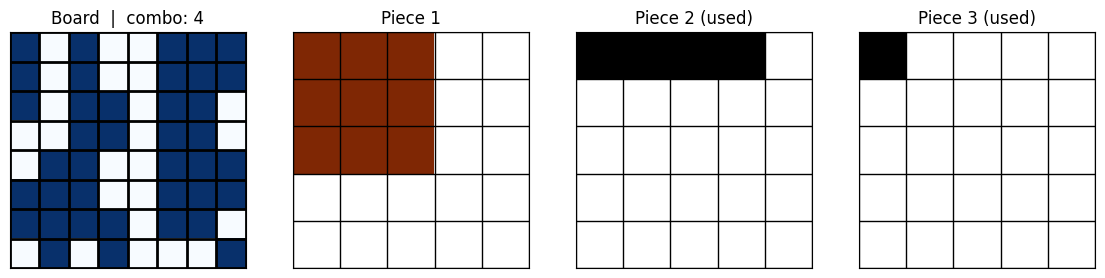


Game Over après 23 steps | Reward finale : 161.6


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

env = BlockBlast3PEnv(render_mode="human")
obs, info = env.reset()

STEPS = 200
total_reward = 0

%matplotlib inline

for step_idx in range(STEPS):
    # Dessiner directement via _draw_figure sans passer par render()
    env._draw_figure()
    
    clear_output(wait=True)
    display(env.fig)
    plt.close(env.fig)
    env.fig = None  # force recréation au prochain step
    
    print(f"Step {step_idx+1} | Combo: {env.combo} | Pieces used: {env.pieces_used.tolist()}")
    print(f"Total reward: {total_reward:.1f}")

    action = agent.select_action(env)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    time.sleep(0.3)

    if terminated or truncated:
        env._draw_figure()
        clear_output(wait=True)
        display(env.fig)
        plt.close(env.fig)
        env.fig = None
        print(f"\nGame Over après {step_idx+1} steps | Reward finale : {total_reward:.1f}")
        break

env.close()

# Teaching avec MCTS

## Collecte

In [ ]:
trainer.load("/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt")
trainer.model = trainer.model.to(torch.device("cuda"))

Loaded <- /Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt  (step 42,516,480 | mean_ret 164.3 over last 100 eps)


In [ ]:
from mct.mcts_collect import collect_mcts_dataset

collect_mcts_dataset(
    trainer    = trainer,
    env_fn     = lambda: BlockBlast3PEnv(),
    n_episodes = 1000,
    save_path  = "/Data/roman.lendormy/rl_checkpoints_2/mcts_dataset_v2.npz",
    device     = torch.device("cuda"),
)

  Episode    50/1000 | return    171.6 | len   20 | mean_ret 367.4 | ETA 134.1min
  Episode   100/1000 | return   2057.5 | len  116 | mean_ret 559.4 | ETA 133.6min
  Episode   150/1000 | return    111.4 | len   17 | mean_ret 581.1 | ETA 128.7min
  Episode   200/1000 | return    553.7 | len   53 | mean_ret 578.0 | ETA 118.4min
  Episode   250/1000 | return    372.2 | len   28 | mean_ret 561.7 | ETA 110.6min
  Episode   300/1000 | return    623.0 | len   46 | mean_ret 571.9 | ETA 102.3min
  Episode   350/1000 | return    251.6 | len   20 | mean_ret 573.0 | ETA 94.7min
  Episode   400/1000 | return    151.6 | len   19 | mean_ret 571.7 | ETA 87.5min
  Episode   450/1000 | return    341.9 | len   25 | mean_ret 576.3 | ETA 79.9min
  Episode   500/1000 | return     60.9 | len   11 | mean_ret 577.8 | ETA 72.4min
  Episode   550/1000 | return   1084.8 | len   69 | mean_ret 586.2 | ETA 65.1min
  Episode   600/1000 | return     91.8 | len   22 | mean_ret 579.5 | ETA 58.0min
  Episode   650/1000 |

{'boards': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         ...,
         [0., 0., 0., ..., 1., 1., 0.],
         [0., 0., 0., ..., 0., 1., 0.],
         [0., 0., 0., ..., 0., 1., 0.]],
 
        ...,
 
        [[1., 1., 1., ..., 0., 1., 1.],
         [0., 0., 0., ..., 0., 1., 1.],
         [0., 0., 0., ..., 0., 1., 1.],
         ...,
         [1., 1., 1., ..., 0., 1., 1.],
         [1., 1., 1., ..., 0.,

In [ ]:
from mct.ppo_finetune import ppo_finetune_on_mcts

history = ppo_finetune_on_mcts(
    trainer      = trainer,
    dataset_path = "/Data/roman.lendormy/rl_checkpoints_2/mcts_dataset_v2.npz",
    save_path    = "/Data/roman.lendormy/rl_checkpoints_2/ppo_mcts_ft_v3.pt",
    device       = torch.device("cuda"),
    n_epochs     = 5,
    lr           = 5e-6,    # 10x plus bas
    clip_eps     = 0.05,    # clipping très serré
    vf_coef      = 0.1,     # réduire le poids de la VF loss
    plot_path    = "/Data/roman.lendormy/rl_checkpoints_2/ft_curves_v3.png",
)

Loading dataset from /Data/roman.lendormy/rl_checkpoints_2/mcts_dataset_v2.npz...
  35,211 steps loaded
Computing value estimates...
Computing old log probabilities...
Loading real rewards and dones...
Computing GAE advantages...

PPO fine-tuning: 5 epochs × 35,211 steps

 Epoch |   PG Loss |   VF Loss |   Entropy |   Clip Fr |  Accuracy
─────────────────────────────────────────────────────────────────
     1 |    0.0260 |  234.9594 |    0.9561 |     0.228 |     64.3%
     2 |    0.0452 |  231.3138 |    0.9407 |     0.317 |     64.1%
     3 |    0.0441 |  230.5582 |    0.9422 |     0.309 |     64.1%
     4 |    0.0427 |  230.0580 |    0.9446 |     0.304 |     64.0%
     5 |    0.0390 |  229.6792 |    0.9494 |     0.288 |     64.0%
Saved -> /Data/roman.lendormy/rl_checkpoints_2/ppo_mcts_ft_v3.pt  (step 42,516,480)

Fine-tuned checkpoint saved -> /Data/roman.lendormy/rl_checkpoints_2/ppo_mcts_ft_v3.pt
Fine-tuning curves saved -> /Data/roman.lendormy/rl_checkpoints_2/ft_curves_v3.png


In [ ]:
import numpy as np
data = np.load("/Data/roman.lendormy/rl_checkpoints_2/mcts_dataset_v2.npz")
print("Rewards min/max/mean:", data["rewards"].min(), data["rewards"].max(), data["rewards"].mean())
print("Dones sum:", data["dones"].sum(), "/ episodes")

Rewards min/max/mean: 0.1 360.0 16.12458
Dones sum: 1000.0 / episodes


In [ ]:
from mct.mcts_agent import compare_ppo_vs_mcts

results = compare_ppo_vs_mcts(
    model      = trainer.model,
    env_fn     = lambda: BlockBlast3PEnv(),
    device     = torch.device("cuda"),
    n_episodes = 50,
)

--- PPO greedy ---
  Episode   10/50 | return    372.3 | length   32 steps
  Episode   20/50 | return     71.5 | length   17 steps
  Episode   30/50 | return    552.2 | length   32 steps
  Episode   40/50 | return   1223.6 | length   56 steps
  Episode   50/50 | return     61.1 | length   14 steps

=== MCTS Evaluation (50 episodes) ===
  Mean return   : 265.09 +/- 244.32
  Median return : 172.45
  Mean length   : 25.5 steps
  Time/round    : 0.0 ms


--- MCTS (depth-3 exhaustive) ---
  Episode   10/50 | return    212.0 | length   29 steps
  Episode   20/50 | return    883.6 | length   53 steps
  Episode   30/50 | return     41.3 | length   16 steps
  Episode   40/50 | return    662.1 | length   32 steps
  Episode   50/50 | return   2437.0 | length  110 steps

=== MCTS Evaluation (50 episodes) ===
  Mean return   : 448.46 +/- 541.76
  Median return : 271.90
  Mean length   : 31.9 steps
  Time/round    : 854.2 ms


=== Comparison ===
  Return gain   : +183.37  (+69.2%)
  Length gain   : 

# PPO online with MCTS

In [4]:
from mct.mcts_ppo_trainer import MCTSPPOTrainer
from blockblast.block_blast_3p_env import BlockBlast3PEnv
import torch, os

os.makedirs("/Data/roman.lendormy/rl_checkpoints_2/mcts_ppo", exist_ok=True)

# 4 envs suffit — le goulot d'étranglement est MCTS pas le GPU
envs = [BlockBlast3PEnv() for _ in range(4)]

mcts_trainer = MCTSPPOTrainer(
    envs       = envs,
    device     = torch.device("cuda"),
    lr         = 1e-4,
    n_steps    = 128,
    n_epochs   = 4,
    batch_size = 256,
    ent_coef   = 0.01,
    vf_coef    = 0.25,
    gae_lambda = 0.98,
    gamma      = 0.99,
)

# Charger le checkpoint original comme point de départ
mcts_trainer.load("/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt")
mcts_trainer.model = mcts_trainer.model.to(torch.device("cuda"))

Loaded <- /Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt  (step 42,516,480 | mean_ret 164.3 over last 100 eps)


In [ ]:
history = mcts_trainer.train(
    total_timesteps  = 5_000_000,
    log_interval     = 1,
    checkpoint_every = 500_000,
    checkpoint_dir   = "/Data/roman.lendormy/rl_checkpoints_2/mcts_ppo",
)


MCTS-PPO — 5,000,000 steps · 9765 updates · 4 envs

  Upd |      Steps |   MeanRet |    MedRet |  MeanLen |   PgLoss |   VfLoss |  Entropy |  ClipFr |    Time
──────────────────────────────────────────────────────────────────────────────────────────────────────────
    1 | 42,516,992 |    229.21 |    141.70 |     23.9 |   0.0072 | 282.2305 |   1.0698 |   0.082 |    252s
    2 | 42,517,504 |    312.23 |    166.75 |     26.1 |   0.0161 | 348.5758 |   1.1115 |   0.147 |    231s
    3 | 42,518,016 |    354.04 |    211.70 |     28.0 |   0.0223 | 198.8566 |   1.0112 |   0.142 |    344s
    4 | 42,518,528 |    421.56 |    256.95 |     30.0 |   0.0330 | 148.7586 |   0.8608 |   0.166 |    277s
